# 11_Forecasting
Forecast archetype-level demand trends (not individual skills)

Input:
master_skill_dataset_v8.csv
skill_demand_history.csv

Output:
archetype_forecast.csv

Forecast Horizon:
2026
2027
2028

In [24]:
import pandas as pd
import numpy as np

from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [25]:
skills = pd.read_csv(
    '../Generated Datasets/master_skill_dataset_v8.csv'
)

history = pd.read_csv(
    '../Generated Datasets/skill_demand_history.csv'
)

print(skills.shape)
print(history.shape)

skills.head()

(114, 13)
(829, 3)


,skill,sub_category,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate,history_found,cluster,pc1,pc2,archetype
0,data analysis,Data Analytics,1.000000,0.326209,0.625994,0.559777,0.634146,0.566533,1,3,3.282909,-5.959951,Future-Proof
1,excel,Data Analytics,0.506295,0.067637,0.340903,0.535307,0.634146,0.566533,1,2,0.823164,-4.208818,Growing
2,quality assurance,Software Engineering,0.442621,0.175857,0.275063,0.305183,0.634146,0.566533,1,2,-0.244958,-3.534908,Growing
3,microsoft excel,Data Analytics,0.314443,0.067637,0.233033,0.394582,0.634146,0.566533,1,2,-0.466162,-3.203326,Growing
4,python,Programming,0.307062,0.631282,0.876458,0.701599,0.951220,0.255955,1,3,5.283296,-1.543775,Future-Proof


In [26]:
history['skill'] = history['skill'].str.lower()
skills['skill'] = skills['skill'].str.lower()

history = history.merge(
    skills[['skill','archetype']],
    on='skill',
    how='inner'
)

print(history.shape)

history.head()

(116, 4)


,skill,year,demand,archetype
0,aws,2021,29138,High-Risk
1,aws,2022,25939,High-Risk
2,angular,2021,14471,High-Risk
3,angular,2022,11138,High-Risk
4,angular,2023,12537,High-Risk


In [27]:
cluster_history = (
    history
    .groupby(['archetype', 'year'])['demand']
    .mean()
    .reset_index()
)

cluster_history

,archetype,year,demand
0,Future-Proof,2021,36865.166667
1,Future-Proof,2022,33666.000000
2,Future-Proof,2023,41968.500000
3,Future-Proof,2024,29466.333333
4,Future-Proof,2025,17308.333333
5,Growing,2021,6052.000000
6,Growing,2022,5355.666667
7,Growing,2023,5433.500000
8,Growing,2024,3692.250000
9,Growing,2025,2355.000000


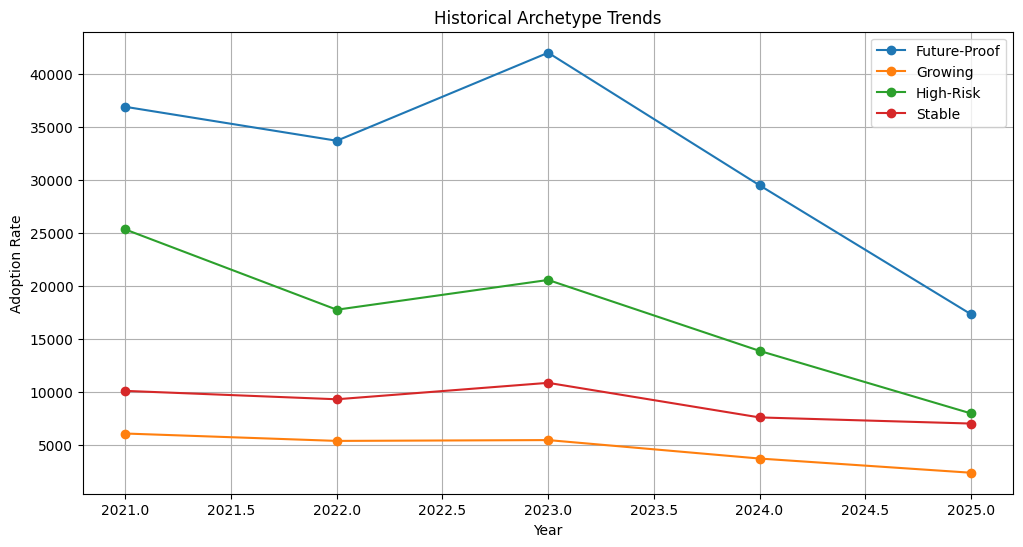

In [28]:
plt.figure(figsize=(12,6))

for archetype in cluster_history['archetype'].unique():

    temp = cluster_history[
        cluster_history['archetype']==archetype
    ]

    plt.plot(
        temp['year'],
        temp['demand'],
        marker='o',
        label=archetype
    )

plt.title('Historical Archetype Trends')
plt.xlabel('Year')
plt.ylabel('Adoption Rate')
plt.legend()
plt.grid(True)

plt.show()

In [29]:
def forecast_archetype(archetype_name):

    temp = cluster_history[
        cluster_history['archetype'] == archetype_name
    ].copy()

    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(
            temp['year'].astype(str) + '-01-01'
        ),
        'y': temp['demand']
    })

    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(prophet_df)

    future = model.make_future_dataframe(
        periods=3,
        freq='Y'
    )

    forecast = model.predict(future)

    return model, forecast

In [30]:
forecast_results = []

for archetype in cluster_history['archetype'].unique():

    model, forecast = forecast_archetype(archetype)

    future = forecast.tail(3)

    forecast_results.append([
        archetype,
        future.iloc[0]['yhat'],
        future.iloc[1]['yhat'],
        future.iloc[2]['yhat']
    ])

forecast_df = pd.DataFrame(
    forecast_results,
    columns=[
        'archetype',
        'forecast_2026',
        'forecast_2027',
        'forecast_2028'
    ]
)

forecast_df

19:01:21 - cmdstanpy - INFO - Chain [1] start processing
19:01:21 - cmdstanpy - INFO - Chain [1] done processing
19:01:21 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


RuntimeError: Error during optimization! Command 'C:\Users\Saanvi\anaconda3\envs\COURSE\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=51391 data file=C:\Users\Saanvi\AppData\Local\Temp\tmpaui7aa8v\1zqwc1dq.json init=C:\Users\Saanvi\AppData\Local\Temp\tmpaui7aa8v\8lf903r6.json output file=C:\Users\Saanvi\AppData\Local\Temp\tmpaui7aa8v\prophet_model86j_x8au\prophet_model-20260610190121.csv method=optimize algorithm=newton iter=10000' failed: 

In [ ]:
for archetype in cluster_history['archetype'].unique():

    model, forecast = forecast_archetype(archetype)

    fig = model.plot(forecast)

    plt.title(
        f'{archetype} Forecast'
    )

    plt.show()

(114, 18)


,skill,forecast_2026,forecast_2027,forecast_2028,forecast_growth,forecast_class
0,data analysis,NaN,NaN,NaN,0.0,Declining
1,excel,NaN,NaN,NaN,0.0,Declining
2,quality assurance,NaN,NaN,NaN,0.0,Declining
3,microsoft excel,NaN,NaN,NaN,0.0,Declining
4,python,NaN,NaN,NaN,0.0,Declining


In [ ]:
forecast_df['cluster_growth_2028'] = (
    forecast_df['forecast_2028']
    -
    forecast_df['forecast_2026']
)

forecast_df

Saved Successfully
(114, 18)


In [ ]:
forecast_df.to_csv(
    '../Generated Datasets/archetype_forecast.csv',
    index=False
)

print("Saved Successfully")

forecast_df

count    264.000000
mean       3.068182
std        1.478326
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        5.000000
dtype: float64